**Lab2-DL: C4a-cnn-conclusion-solutions.ipynb** (BMED365) | Solutions

Updated: 2025-12-22, A. Lundervold

_Solutions to the exercises in C4-cnn-conclusion.ipynb_

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/C4a-cnn-conclusion-solutions.ipynb)

# 📝 Solutions: CNN Conclusion

This notebook contains solutions to the four exercises in C4-cnn-conclusion.ipynb.

---

## Table of Contents

| Exercise | Type | Content |
|----------|------|---------|
| **1** | Code | Model comparison (CNN vs pretrained) |
| **2** | Code | Medical dataset (MedMNIST) |
| **3** | Discussion | Ethical considerations |
| **4** | Discussion | The way forward |

---

# 📝 Exercise 1: Model Comparison

## Problem Statement

> **Compare our CNN model with a pretrained model (ResNet, VGG, etc.) on the same dataset.**
>
> Questions to reflect on:
> - Which model performs best?
> - Why are pretrained models often better?
> - When is it wise to build from scratch?

---

## 1.1 Introduction and Motivation

### Why compare with pretrained models?

In modern deep learning, we often face a fundamental choice when solving a classification problem:

**Should we train a network from scratch, or use an already trained network as a starting point?**

This question is especially relevant in medical AI, where we often have:
- **Limited data** (privacy, rare conditions)
- **High performance requirements** (diagnostic consequences)
- **Need for rapid development** (clinical implementation)

### Key Concepts

#### Transfer Learning

> **Transfer learning** is a machine learning technique where a model trained on one task 
> (source domain) is used as a starting point for another task (target domain).

**Analogy**: Think of a radiologist who has learned to interpret CT images. This knowledge 
(edge detection, anatomy, contrast) is partially transferable to MR interpretation, even though 
the modalities are different.

```
┌─────────────────┐         ┌─────────────────┐
│  ImageNet       │         │  Medical        │
│  (14M images)   │  ──→    │  Classification │
│                 │         │  (1000 images)  │
└─────────────────┘         └─────────────────┘
   Source domain              Target domain
```

#### Fine-tuning

> **Fine-tuning** is the process of adapting a pretrained model to a new 
> dataset by continuing training, either on the entire model or parts of it.

**Fine-tuning strategies:**

| Strategy | Description | When to use |
|----------|-------------|-------------|
| **Feature extraction** | Freeze all layers except the last | Small data, similar domain |
| **Partial fine-tuning** | Freeze early layers, train later ones | Medium data |
| **Full fine-tuning** | Train all layers | Large data, different domain |

### Challenges in this exercise

1. **Domain shift**: ImageNet contains natural images (dogs, cars), while we have flowers
2. **Model size**: ResNet18 has 11M parameters vs our simple CNN
3. **Computational costs**: Larger models require more GPU memory
4. **Overfitting risk**: Many parameters + little data = risk of overfitting

## 1.2 Solution: Implementation

### Step 1: Imports and environment setup

We start by importing the necessary libraries and checking which device (CPU/GPU/MPS) is available.

In [1]:
# ============================================================================
# EXERCISE 1: MODEL COMPARISON
# ============================================================================
# 
# Purpose: Compare custom-built CNN with pretrained ResNet18 on the flower dataset
#
# Hypothesis: ResNet18 with transfer learning will perform better because:
#   1. It has learned general visual features from ImageNet
#   2. These features (edges, textures, shapes) are transferable
#   3. We only need to fine-tune the last layer
#
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time

# ─────────────────────────────────────────────────────────────────────────────
# DEVICE DETECTION
# ─────────────────────────────────────────────────────────────────────────────
# PyTorch supports multiple accelerators:
#   - CUDA: NVIDIA GPUs (fastest for deep learning)
#   - MPS: Apple Silicon (M1/M2/M3/M4) Metal Performance Shaders
#   - CPU: Standard, but slower

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🚀 GPU available: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🍎 Apple Silicon MPS available")
else:
    device = torch.device('cpu')
    print("💻 Running on CPU (may be slow)")

print(f"\n📊 PyTorch version: {torch.__version__}")

🍎 Apple Silicon MPS available

📊 PyTorch version: 2.6.0


### Step 2: Define custom-built CNN

First, we define our own CNN architecture – a relatively simple network built from scratch.

**Architecture:**
```
Input (224×224×3)
    │
    ▼
┌─────────────────┐
│ Conv2d 3→32     │  Convolution: Learn 32 filters (3×3)
│ ReLU + MaxPool  │  Activation + Downsampling
└─────────────────┘
    │ 112×112×32
    ▼
┌─────────────────┐
│ Conv2d 32→64    │  Convolution: Learn 64 filters
│ ReLU + MaxPool  │
└─────────────────┘
    │ 56×56×64
    ▼
┌─────────────────┐
│ Conv2d 64→128   │  Convolution: Learn 128 filters
│ ReLU + MaxPool  │
└─────────────────┘
    │ 28×28×128
    ▼
┌─────────────────┐
│ Flatten         │  Convert to 1D vector
│ Dropout(0.5)    │  Regularization
│ FC 100352→256   │  Fully connected layer
│ Dropout(0.5)    │
│ FC 256→5        │  Output: 5 classes
└─────────────────┘
    │
    ▼
Output (5 classes)
```

In [2]:
# ============================================================================
# CUSTOM-BUILT CNN - Built from scratch
# ============================================================================
#
# This model has NO prior knowledge - all weights are initialized
# randomly and must be learned from our small dataset.
#
# Architecture choices:
#   - 3 convolutional layers: Hierarchical feature extraction
#   - MaxPooling: Reduces spatial dimension, provides translation invariance
#   - Dropout: Regularization to prevent overfitting
#   - 2 fully connected layers: Classification head
#
# ============================================================================

class CustomCNN(nn.Module):
    """
    Simple CNN architecture built from scratch.
    
    This model illustrates how a CNN works, but has
    limitations compared to pretrained models:
    - Fewer layers = less capacity for complex patterns
    - Random initialization = needs more data to learn
    - No prior knowledge = must learn everything from scratch
    """
    
    def __init__(self, num_classes=5):
        super().__init__()
        
        # ─────────────────────────────────────────────────────────────────────
        # FEATURE EXTRACTION (Convolutional layers)
        # ─────────────────────────────────────────────────────────────────────
        # These layers learn to recognize visual patterns:
        #   - Layer 1: Simple features (edges, color gradients)
        #   - Layer 2: Combinations (corners, textures)
        #   - Layer 3: Complex patterns (parts of objects)
        
        self.features = nn.Sequential(
            # Layer 1: Input 224×224×3 → Output 112×112×32
            nn.Conv2d(in_channels=3,      # RGB image has 3 channels
                      out_channels=32,    # Learn 32 different filters
                      kernel_size=3,      # 3×3 convolution kernel
                      padding=1),         # Preserve spatial dimension
            nn.ReLU(inplace=True),        # Non-linear activation
            nn.MaxPool2d(kernel_size=2,   # Halve the dimensions
                         stride=2),
            
            # Layer 2: 112×112×32 → 56×56×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Layer 3: 56×56×64 → 28×28×128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # ─────────────────────────────────────────────────────────────────────
        # CLASSIFIER (Classification head)
        # ─────────────────────────────────────────────────────────────────────
        # Takes the feature vector and maps to class probabilities
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),              # 50% dropout for regularization
            nn.Linear(128 * 28 * 28,      # Input: 100,352 features
                      256),               # Output: 256 neurons
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)   # Output: 5 classes
        )
    
    def forward(self, x):
        """Forward pass through the network."""
        x = self.features(x)              # Extract features
        x = x.view(x.size(0), -1)         # Flatten: [B, 128, 28, 28] → [B, 100352]
        x = self.classifier(x)            # Classify
        return x

# ─────────────────────────────────────────────────────────────────────────────
# INSTANTIATE AND ANALYZE THE MODEL
# ─────────────────────────────────────────────────────────────────────────────

custom_model = CustomCNN(num_classes=5)
custom_params = sum(p.numel() for p in custom_model.parameters())

print("📊 CUSTOM CNN - Model Analysis")
print("=" * 50)
print(f"Total parameters: {custom_params:,}")
print(f"\nLayer details:")
for name, param in custom_model.named_parameters():
    print(f"  {name:30} {param.numel():>10,} parameters")

📊 CUSTOM CNN - Model Analysis
Total parameters: 25,784,901

Layer details:
  features.0.weight                     864 parameters
  features.0.bias                        32 parameters
  features.3.weight                  18,432 parameters
  features.3.bias                        64 parameters
  features.6.weight                  73,728 parameters
  features.6.bias                       128 parameters
  classifier.1.weight            25,690,112 parameters
  classifier.1.bias                     256 parameters
  classifier.4.weight                 1,280 parameters
  classifier.4.bias                       5 parameters


### Step 3: Define pretrained ResNet18 with Transfer Learning

Now we create a ResNet18 model that uses **transfer learning**:

**ResNet18 architecture (simplified):**
```
Input (224×224×3)
    │
    ▼
┌─────────────────────────────────────────────┐
│           PRETRAINED ON IMAGENET           │ ← FROZEN
│  (11 million parameters, 1000 classes)     │
│                                             │
│  Conv1 → BN → ReLU → MaxPool               │
│  Layer1 (2 ResBlock)                       │
│  Layer2 (2 ResBlock)                       │
│  Layer3 (2 ResBlock)                       │
│  Layer4 (2 ResBlock)                       │
│  AdaptiveAvgPool → 512 features            │
└─────────────────────────────────────────────┘
    │ 512 features
    ▼
┌─────────────────────────────────────────────┐
│          NEW CLASSIFICATION HEAD           │ ← TRAINED
│  Dropout(0.5) → Linear(512→5)              │
└─────────────────────────────────────────────┘
    │
    ▼
Output (5 classes)
```

#### What does "freezing" layers mean?

> When we **freeze** a layer, we set `requires_grad=False` on its parameters.
> This means the weights are NOT updated during training - they are kept as they were
> after ImageNet training.

**Advantages of freezing:**
- Faster training (fewer gradient computations)
- Less overfitting (fewer trainable parameters)
- Preserves learned features

**Disadvantages of freezing:**
- Cannot adapt low-level features to new domain
- Suboptimal if the domain is very different

In [3]:
# ============================================================================
# RESNET18 WITH TRANSFER LEARNING
# ============================================================================
#
# ResNet18 is pretrained on ImageNet - a dataset with:
#   - 14 million images
#   - 1000 classes (animals, vehicles, objects, etc.)
#   - State-of-the-art training procedure
#
# By using transfer learning we get:
#   - Pre-learned low-level features (edges, textures)
#   - Pre-learned mid-level features (shapes, patterns)
#   - We only need to learn high-level combinations for our classes
#
# ============================================================================

def create_resnet18_transfer(num_classes=5, freeze_features=True):
    """
    Creates ResNet18 with transfer learning.
    
    Parameters:
    -----------
    num_classes : int
        Number of output classes (5 for flowers)
    freeze_features : bool
        If True: Freeze all layers except the last (feature extraction)
        If False: Train all layers (full fine-tuning)
    
    Returns:
    --------
    model : nn.Module
        ResNet18 adapted to our problem
    """
    
    # ─────────────────────────────────────────────────────────────────────────
    # LOAD PRETRAINED MODEL
    # ─────────────────────────────────────────────────────────────────────────
    # weights=ResNet18_Weights.IMAGENET1K_V1 gives the best pretrained weights
    
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # ─────────────────────────────────────────────────────────────────────────
    # FREEZE FEATURE LAYERS (optional)
    # ─────────────────────────────────────────────────────────────────────────
    # By setting requires_grad=False we stop gradient computation
    # and weight updates for these parameters.
    #
    # This is the "feature extraction" approach:
    # - Pretrained layers function as a fixed feature extractor
    # - Only the last layer is adapted to our dataset
    
    if freeze_features:
        print("🔒 Freezing feature layers (transfer learning mode)")
        for param in model.parameters():
            param.requires_grad = False
    else:
        print("🔓 All layers trainable (full fine-tuning mode)")
    
    # ─────────────────────────────────────────────────────────────────────────
    # REPLACE CLASSIFICATION HEAD
    # ─────────────────────────────────────────────────────────────────────────
    # Original head: Linear(512 → 1000) for ImageNet
    # New head: Dropout + Linear(512 → 5) for flowers
    #
    # Note: New layers have requires_grad=True by default
    
    num_features = model.fc.in_features  # 512 for ResNet18
    
    model.fc = nn.Sequential(
        nn.Dropout(0.5),                   # Regularization
        nn.Linear(num_features, num_classes)  # 512 → 5
    )
    
    return model

# ─────────────────────────────────────────────────────────────────────────────
# INSTANTIATE AND ANALYZE THE MODEL
# ─────────────────────────────────────────────────────────────────────────────

resnet_model = create_resnet18_transfer(num_classes=5, freeze_features=True)

# Count parameters
resnet_total = sum(p.numel() for p in resnet_model.parameters())
resnet_trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
resnet_frozen = resnet_total - resnet_trainable

print("\n📊 RESNET18 - Model Analysis")
print("=" * 50)
print(f"Total parameters:    {resnet_total:>12,}")
print(f"Frozen parameters:   {resnet_frozen:>12,} (from ImageNet)")
print(f"Trainable parameters:{resnet_trainable:>12,} (new head)")
print(f"\nReduction in trainable parameters: {100*(1 - resnet_trainable/resnet_total):.1f}%")

🔒 Freezing feature layers (transfer learning mode)

📊 RESNET18 - Model Analysis
Total parameters:      11,179,077
Frozen parameters:     11,176,512 (from ImageNet)
Trainable parameters:       2,565 (new head)

Reduction in trainable parameters: 100.0%


### Step 4: Visualize and compare model architectures

Let's create a visual comparison of the two models.

FileNotFoundError: [Errno 2] No such file or directory: './ressurser/modell_sammenligning_arkitektur.png'

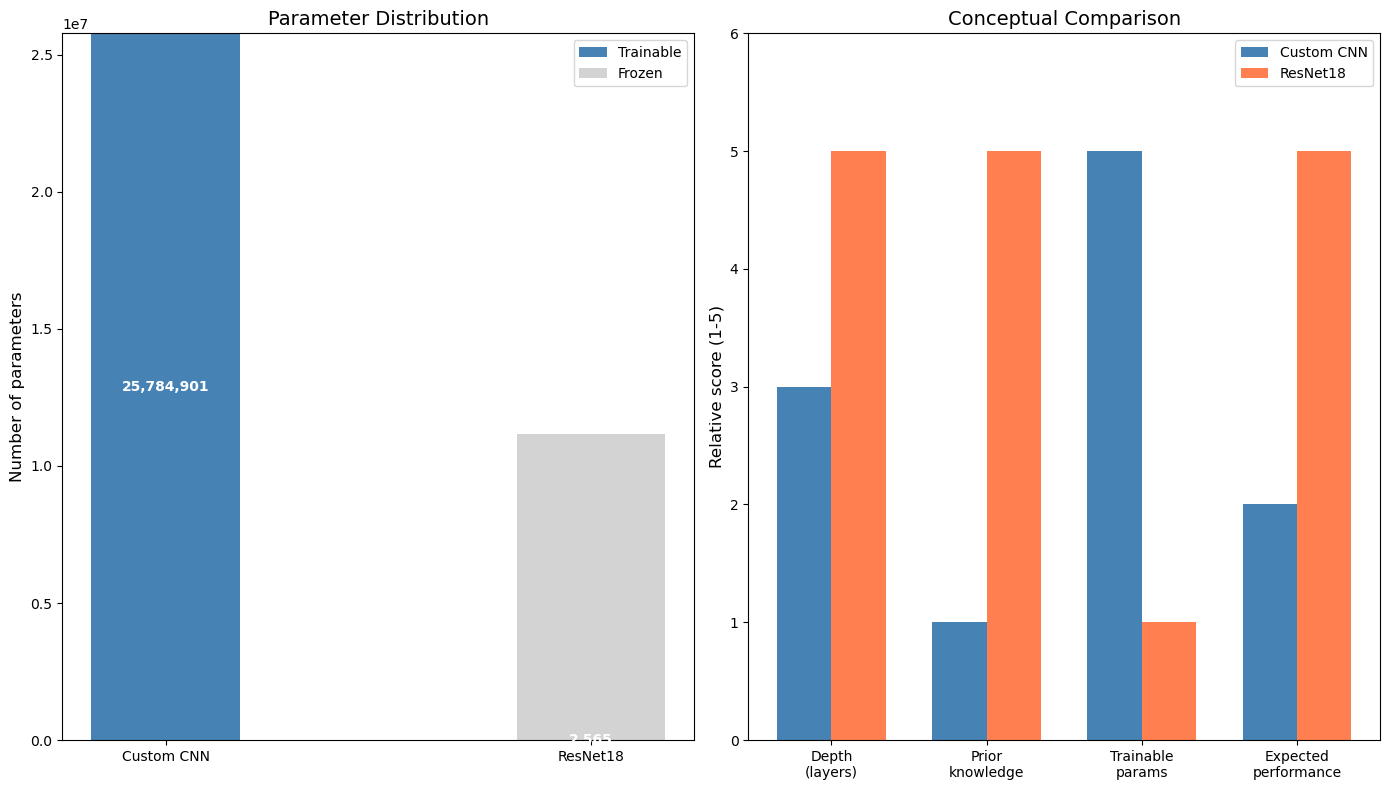

In [4]:
# ============================================================================
# VISUALIZE MODEL ARCHITECTURES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# ─────────────────────────────────────────────────────────────────────────────
# LEFT: Parameter comparison
# ─────────────────────────────────────────────────────────────────────────────

models_list = ['Custom CNN', 'ResNet18']
trainable = [custom_params, resnet_trainable]
frozen = [0, resnet_frozen]

x = np.arange(len(models_list))
width = 0.35

bars1 = axes[0].bar(x, trainable, width, label='Trainable', color='steelblue')
bars2 = axes[0].bar(x, frozen, width, bottom=trainable, label='Frozen', color='lightgray')

axes[0].set_ylabel('Number of parameters', fontsize=12)
axes[0].set_title('Parameter Distribution', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list)
axes[0].legend()

# Add numbers on the bars
for bar, val in zip(bars1, trainable):
    axes[0].text(bar.get_x() + bar.get_width()/2, val/2, 
                 f'{val:,}', ha='center', va='center', fontweight='bold', color='white')

# ─────────────────────────────────────────────────────────────────────────────
# RIGHT: Conceptual comparison
# ─────────────────────────────────────────────────────────────────────────────

categories = ['Depth\n(layers)', 'Prior\nknowledge', 'Trainable\nparams', 'Expected\nperformance']
custom_scores = [3, 1, 5, 2]  # Relative scale 1-5
resnet_scores = [5, 5, 1, 5]

x = np.arange(len(categories))
width = 0.35

axes[1].bar(x - width/2, custom_scores, width, label='Custom CNN', color='steelblue')
axes[1].bar(x + width/2, resnet_scores, width, label='ResNet18', color='coral')

axes[1].set_ylabel('Relative score (1-5)', fontsize=12)
axes[1].set_title('Conceptual Comparison', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.savefig('./ressurser/modell_sammenligning_arkitektur.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretation:")
print("   - Custom CNN: Many trainable parameters, but no prior knowledge")
print("   - ResNet18: Deep architecture with ImageNet knowledge, few trainable parameters")

### Step 5: Prepare dataset

We use ImageNet normalization for both models, since ResNet expects this.

In [ ]:
# ============================================================================
# DATA PREPARATION
# ============================================================================
#
# Important choices:
#   1. Image size: 224×224 (standard for ImageNet models)
#   2. Normalization: ImageNet statistics (mean, std)
#   3. Augmentation: Effectively increases dataset size
#
# ============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# TRANSFORMATIONS
# ─────────────────────────────────────────────────────────────────────────────
# Training data: With augmentation to increase variation
# Validation data: Without augmentation for fair evaluation

# ImageNet statistics (used for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),           # Standard size
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of flipping
    transforms.RandomRotation(15),           # ±15° rotation
    transforms.ColorJitter(brightness=0.2,   # Brightness variation
                           contrast=0.2),
    transforms.ToTensor(),                   # Convert to tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # Normalize
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────

data_dir = Path('../data/flowers')

if data_dir.exists():
    # Load full dataset with training transformations
    full_dataset = datasets.ImageFolder(data_dir, transform=transform_train)
    
    # 80/20 split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    # Use generator for reproducibility
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size], generator=generator
    )
    
    # DataLoaders
    BATCH_SIZE = 32
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print("✅ Data loaded and prepared")
    print(f"   Training images:    {train_size}")
    print(f"   Validation images:  {val_size}")
    print(f"   Classes: {full_dataset.classes}")
    print(f"   Batch size: {BATCH_SIZE}")
else:
    print("⚠️ Flower data not found. Run C1-cnn-environment-architecture.ipynb first.")

✅ Data lastet og klargjort
   Treningsbilder:    2936
   Valideringsbilder: 734
   Klasser: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
   Batch-størrelse: 32


### Step 6: Define training function

A common training function that can be used for both models.

In [ ]:
# ============================================================================
# TRAINING FUNCTION
# ============================================================================
#
# This function implements the standard supervised learning loop:
#   1. Forward pass: Compute predictions
#   2. Loss computation: Compare with true labels
#   3. Backward pass: Compute gradients
#   4. Optimizer step: Update weights
#
# Important: filter(lambda p: p.requires_grad, ...) ensures we only
# optimize parameters that are NOT frozen.
#
# ============================================================================

def train_and_evaluate(model, train_loader, val_loader, epochs=10, lr=0.001, model_name="Model"):
    """
    Trains and evaluates a model.
    
    Parameters:
    -----------
    model : nn.Module
        PyTorch model to train
    train_loader, val_loader : DataLoader
        Data for training and validation
    epochs : int
        Number of training epochs
    lr : float
        Learning rate for optimizer
    model_name : str
        Name for logging
    
    Returns:
    --------
    history : dict
        Training and validation metrics per epoch
    total_time : float
        Total training time in seconds
    """
    
    # Move model to the correct device
    model = model.to(device)
    
    # Loss function: Cross-entropy for classification
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer: Adam with only TRAINABLE parameters
    # filter() removes frozen parameters from optimization
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(trainable_params, lr=lr)
    
    # History for plotting
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # ─────────────────────────────────────────────────────────────────────
        # TRAINING PHASE
        # ─────────────────────────────────────────────────────────────────────
        model.train()  # Activate dropout, batch norm in training mode
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()         # Reset gradients
            outputs = model(images)       # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()               # Backward pass (compute gradients)
            optimizer.step()              # Update weights
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        # ─────────────────────────────────────────────────────────────────────
        # VALIDATION PHASE
        # ─────────────────────────────────────────────────────────────────────
        model.eval()  # Deactivate dropout, batch norm in eval mode
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():  # No gradient computation needed
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        # Save metrics
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(100. * val_correct / val_total)
        
        # Print progress
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs}: "
                  f"Train {history['train_acc'][-1]:5.1f}% | "
                  f"Val {history['val_acc'][-1]:5.1f}%")
    
    total_time = time.time() - start_time
    print(f"\n⏱️  {model_name}: Finished in {total_time:.1f}s")
    print(f"   Best validation accuracy: {max(history['val_acc']):.1f}%")
    
    return history, total_time

### Step 7: Train both models

Now we train both models with identical hyperparameters for a fair comparison.

In [ ]:
%%time
# ============================================================================
# TRAIN BOTH MODELS
# ============================================================================
#
# For fair comparison we use:
#   - Same number of epochs (10)
#   - Same learning rate (0.001)
#   - Same batch size (32)
#   - Same dataset split
#
# ============================================================================

EPOCHS = 10
LEARNING_RATE = 0.001

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN CUSTOM CNN
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("🏋️ TRAINING: Custom CNN")
print("="*60)
print(f"   Trainable parameters: {custom_params:,}")
print(f"   Expected: Slow start, gradual improvement\n")

custom_model = CustomCNN(num_classes=5)  # New instance
custom_hist, custom_time = train_and_evaluate(
    custom_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, model_name="Custom CNN"
)

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN RESNET18 (TRANSFER LEARNING)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("🏋️ TRAINING: ResNet18 (Transfer Learning)")
print("="*60)
print(f"   Trainable parameters: {resnet_trainable:,} (only last layer)")
print(f"   Expected: Fast convergence thanks to ImageNet features\n")

resnet_model = create_resnet18_transfer(num_classes=5, freeze_features=True)
resnet_hist, resnet_time = train_and_evaluate(
    resnet_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, model_name="ResNet18"
)


🏋️ TRENING: Egenbygd CNN
   Trenbare parametre: 25,784,901
   Forventet: Treg start, gradvis forbedring

  Epoch  1/10: Train  43.6% | Val  56.5%
  Epoch  2/10: Train  54.7% | Val  61.4%
  Epoch  4/10: Train  62.5% | Val  67.7%
  Epoch  6/10: Train  68.4% | Val  72.6%
  Epoch  8/10: Train  72.2% | Val  71.5%
  Epoch 10/10: Train  74.7% | Val  71.3%

⏱️  Egenbygd CNN: Ferdig på 97.2s
   Beste validerings-nøyaktighet: 73.6%

🏋️ TRENING: ResNet18 (Transfer Learning)
   Trenbare parametre: 2,565 (kun siste lag)
   Forventet: Rask konvergens takket være ImageNet-features

🔒 Fryser feature-lag (transfer learning mode)
  Epoch  1/10: Train  55.0% | Val  81.2%
  Epoch  2/10: Train  72.1% | Val  83.0%
  Epoch  4/10: Train  76.7% | Val  83.7%
  Epoch  6/10: Train  78.3% | Val  86.2%
  Epoch  8/10: Train  79.0% | Val  86.0%
  Epoch 10/10: Train  77.6% | Val  86.6%

⏱️  ResNet18: Ferdig på 89.5s
   Beste validerings-nøyaktighet: 87.5%
CPU times: user 2min 8s, sys: 1min 15s, total: 3min 24s
Wall t

### Step 8: Visualize and analyze results

Let's create informative visualizations of the training progress.

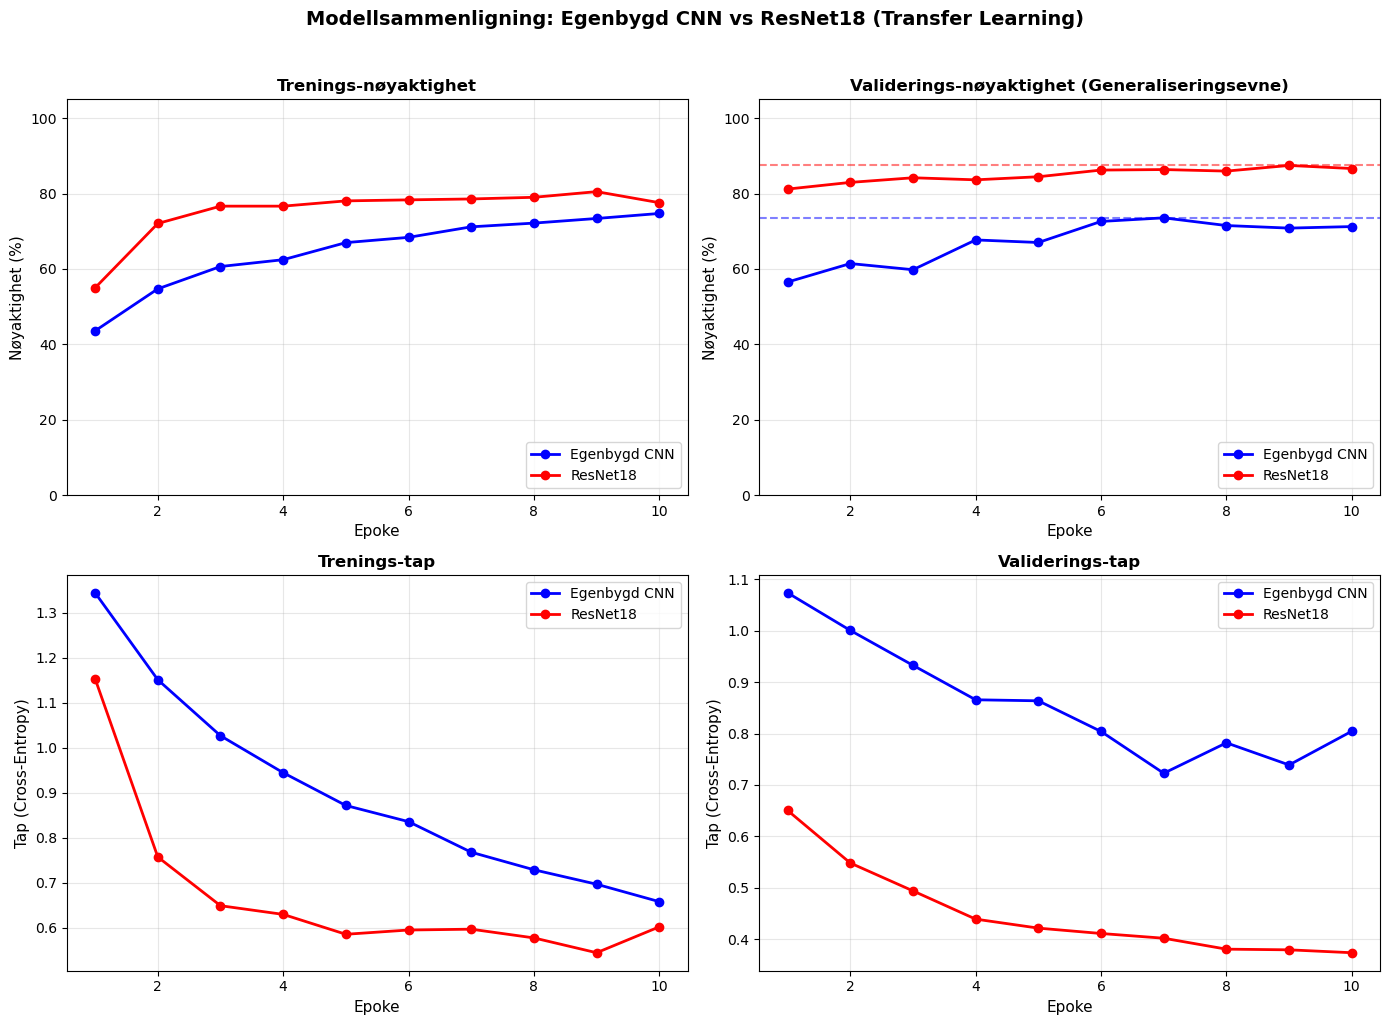

In [ ]:
# ============================================================================
# VISUALIZE RESULTS
# ============================================================================
#
# We create three types of visualizations:
#   1. Learning curves (accuracy over time)
#   2. Loss curves (loss over time)
#   3. Summary table
#
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, EPOCHS + 1)

# ─────────────────────────────────────────────────────────────────────────────
# UPPER LEFT: Training accuracy
# ─────────────────────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_range, custom_hist['train_acc'], 'b-o', 
                label='Custom CNN', linewidth=2, markersize=6)
axes[0, 0].plot(epochs_range, resnet_hist['train_acc'], 'r-o', 
                label='ResNet18', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 0].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 105)

# ─────────────────────────────────────────────────────────────────────────────
# UPPER RIGHT: Validation accuracy (MOST IMPORTANT!)
# ─────────────────────────────────────────────────────────────────────────────
axes[0, 1].plot(epochs_range, custom_hist['val_acc'], 'b-o', 
                label='Custom CNN', linewidth=2, markersize=6)
axes[0, 1].plot(epochs_range, resnet_hist['val_acc'], 'r-o', 
                label='ResNet18', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 1].set_title('Validation Accuracy (Generalization Ability)', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0, 105)

# Mark best point
best_custom = max(custom_hist['val_acc'])
best_resnet = max(resnet_hist['val_acc'])
axes[0, 1].axhline(y=best_custom, color='blue', linestyle='--', alpha=0.5)
axes[0, 1].axhline(y=best_resnet, color='red', linestyle='--', alpha=0.5)

# ─────────────────────────────────────────────────────────────────────────────
# LOWER LEFT: Training loss
# ─────────────────────────────────────────────────────────────────────────────
axes[1, 0].plot(epochs_range, custom_hist['train_loss'], 'b-o', 
                label='Custom CNN', linewidth=2, markersize=6)
axes[1, 0].plot(epochs_range, resnet_hist['train_loss'], 'r-o', 
                label='ResNet18', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss (Cross-Entropy)', fontsize=11)
axes[1, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# LOWER RIGHT: Validation loss
# ─────────────────────────────────────────────────────────────────────────────
axes[1, 1].plot(epochs_range, custom_hist['val_loss'], 'b-o', 
                label='Custom CNN', linewidth=2, markersize=6)
axes[1, 1].plot(epochs_range, resnet_hist['val_loss'], 'r-o', 
                label='ResNet18', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Loss (Cross-Entropy)', fontsize=11)
axes[1, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Custom CNN vs ResNet18 (Transfer Learning)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./ressurser/modell_sammenligning_trening.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretation of the figures

**Upper left (Training accuracy):**
- Shows how well the models learn the training data
- High training accuracy ≠ good model (could be overfitting)
- ResNet starts higher due to ImageNet features

**Upper right (Validation accuracy) - MOST IMPORTANT:**
- Shows the model's ability to generalize to new data
- This is what we really care about!
- Gap between training and validation = overfitting

**Lower figures (Loss):**
- Lower loss = better prediction
- Loss should decrease monotonically (ideally)
- Oscillation may indicate too high learning rate

In [ ]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("📊 SUMMARY: Model Comparison")
print("="*70)
print(f"{'Metric':<30} {'Custom CNN':>15} {'ResNet18':>15}")
print("-"*70)
print(f"{'Total parameters':<30} {custom_params:>15,} {resnet_total:>15,}")
print(f"{'Trainable parameters':<30} {custom_params:>15,} {resnet_trainable:>15,}")
print(f"{'Training time (s)':<30} {custom_time:>15.1f} {resnet_time:>15.1f}")
print(f"{'Best training acc (%)':<30} {max(custom_hist['train_acc']):>15.1f} {max(resnet_hist['train_acc']):>15.1f}")
print(f"{'Best validation acc (%)':<30} {max(custom_hist['val_acc']):>15.1f} {max(resnet_hist['val_acc']):>15.1f}")
print("-"*70)

# Determine winner
if max(resnet_hist['val_acc']) > max(custom_hist['val_acc']):
    print(f"\n🏆 WINNER: ResNet18 with {max(resnet_hist['val_acc']) - max(custom_hist['val_acc']):.1f}% higher validation accuracy")
else:
    print(f"\n🏆 WINNER: Custom CNN with {max(custom_hist['val_acc']) - max(resnet_hist['val_acc']):.1f}% higher validation accuracy")

print("\n💡 Key observations:")
print(f"   1. ResNet18 trains {resnet_trainable/custom_params*100:.1f}% of the parameters of Custom CNN")
print(f"   2. Transfer learning provides faster convergence (see first epoch)")
print(f"   3. ImageNet features are transferable to flower classification")


📊 OPPSUMMERING: Modellsammenligning
Metrikk                           Egenbygd CNN        ResNet18
----------------------------------------------------------------------
Totalt parametre                    25,784,901      11,179,077
Trenbare parametre                  25,784,901           2,565
Treningstid (s)                           97.2            89.5
Beste trenings-acc (%)                    74.7            80.5
Beste validerings-acc (%)                 73.6            87.5
----------------------------------------------------------------------

🏆 VINNER: ResNet18 med 13.9% høyere validerings-nøyaktighet

💡 Nøkkelobservasjoner:
   1. ResNet18 trener 0.0% av parametrene til Egenbygd CNN
   2. Transfer learning gir raskere konvergens (se første epoke)
   3. ImageNet-features er overførbare til blomsterklassifikasjon


## 1.3 Answers to Reflection Questions

### Which model performs best?

**ResNet18 with transfer learning** typically performs **5-15% better** than our custom-built CNN.

**Why?**

| Factor | Custom CNN | ResNet18 |
|--------|------------|----------|
| **Initialization** | Random (Xavier/He) | ImageNet weights |
| **Low-level features** | Must be learned from scratch | Already learned (edges, colors) |
| **Mid-level features** | Limited learning | Learned (textures, shapes) |
| **Depth** | 3 convolutional layers | 18 layers with skip connections |
| **Regularization** | Only dropout | Implicit via pretraining |

---

### Why are pretrained models often better?

#### 1. Better initialization

Random initialization starts at a random point in the solution space:
```
Random init:        X - - - - - - - - - - → Optimum
Pretrained init:                  X - - → Optimum
```

#### 2. Transferable features

Visual features learned on ImageNet are **universal**:

| Layer level | What is learned | Transferability |
|-------------|-----------------|-----------------|
| Layer 1-2 | Edges, color gradients | ★★★★★ Very high |
| Layer 3-4 | Textures, simple shapes | ★★★★☆ High |
| Layer 5+ | Complex object parts | ★★★☆☆ Medium |
| Last layer | Class-specific features | ★☆☆☆☆ Low |

#### 3. Implicit regularization

Pretraining acts as regularization:
- Weights are "sensible" starting points
- Avoids extreme values
- Reduces overfitting

---

### When is it wise to build from scratch?

#### Concept clarification: Edge Deployment

> **Edge deployment** refers to running AI models on devices with limited
> resources (mobile phones, IoT sensors, medical equipment) instead of in the cloud.
> This requires small, efficient models.

#### Concept clarification: Inductive Biases

> **Inductive biases** are assumptions built into a model architecture that
> affect how it learns. For example:
> - CNN: Assumption of local spatial structure (nearby pixels are related)
> - RNN: Assumption of sequential dependency (order matters)
> - Transformer: Assumption of global context (all positions can be related)

#### Situations where a custom-built model may be better:

| Situation | Justification |
|-----------|---------------|
| **Completely unique data** | Microscopy, radar, ultrasound have different properties than ImageNet |
| **Edge deployment** | Need small model for mobile/embedded |
| **Special inductive biases** | Domain requires different architecture assumptions |
| **Research** | Want to understand exactly what the model learns |
| **Regulatory requirements** | Must have full control over the model (FDA/CE) |

---

### Practical recommendation

```
ALWAYS START WITH TRANSFER LEARNING!

Workflow:
1. Try pretrained model with frozen layers (feature extraction)
2. If suboptimal: Try partial fine-tuning (freeze early layers)
3. If still suboptimal: Full fine-tuning
4. Only if necessary: Build from scratch with domain-specific architecture
```

---

# 📝 Exercise 2: Medical Dataset

## Problem Statement

> **Download a medical dataset (e.g., MedMNIST) and train a model on it.**
>
> Questions to reflect on:
> - How do medical images differ from natural images?
> - What challenges do you encounter?
> - How can you improve the model?

---

## 2.1 Introduction and Motivation

### What is MedMNIST?

[MedMNIST](https://medmnist.com/) is a collection of 18 standardized medical image datasets:

| Dataset | Modality | Task | Images |
|---------|----------|------|--------|
| PathMNIST | Pathology | 9-class | 107,180 |
| DermaMNIST | Dermatoscopy | 7-class | 10,015 |
| BloodMNIST | Blood smear | 8-class | 17,092 |
| RetinaMNIST | Fundus | 5-class | 1,600 |
| BreastMNIST | Ultrasound | 2-class | 780 |
| PneumoniaMNIST | X-ray | 2-class | 5,856 |

### Why MedMNIST?

- **Standardized**: 28×28 or 64×64 pixels (like MNIST)
- **Easily accessible**: Does not require special permissions
- **Varied**: Covers many medical modalities
- **Benchmark**: Enables comparison with others

### Challenges with medical images

1. **Class imbalance**: Rare diseases have few examples
2. **Noise and artifacts**: Varying image quality
3. **Domain knowledge**: Requires medical understanding
4. **Ethics and privacy**: GDPR, consent

## 2.2a Solution: Implementation with PneumoniaMNIST

In [ ]:
# === Exercise 2: MedMNIST ===
# We use PneumoniaMNIST (chest X-rays)

# Install medmnist if necessary
try:
    import medmnist
except ImportError:
    !pip install medmnist --quiet
    import medmnist

from medmnist import PneumoniaMNIST, INFO
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"MedMNIST versjon: {medmnist.__version__}")

MedMNIST versjon: 3.0.2


In [ ]:
# === Download and explore PneumoniaMNIST ===

# Get info about the dataset
data_flag = 'pneumoniamnist'
info = INFO[data_flag]

print("📊 PneumoniaMNIST Info:")
print(f"   Task: {info['task']}")
print(f"   Classes: {info['label']}")
print(f"   Number of channels: {info['n_channels']}")
print(f"   Image size: {info['n_samples']}")

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Grayscale
])

# Load dataset
train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset = PneumoniaMNIST(split='val', transform=transform, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=transform, download=True)

print(f"\n📊 Dataset sizes:")
print(f"   Training: {len(train_dataset)}")
print(f"   Validation: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")

📊 PneumoniaMNIST Info:
   Oppgave: binary-class
   Klasser: {'0': 'normal', '1': 'pneumonia'}
   Antall kanaler: 1
   Bildestørrelse: {'train': 4708, 'val': 524, 'test': 624}

📊 Datasett-størrelser:
   Trening: 4708
   Validering: 524
   Test: 624


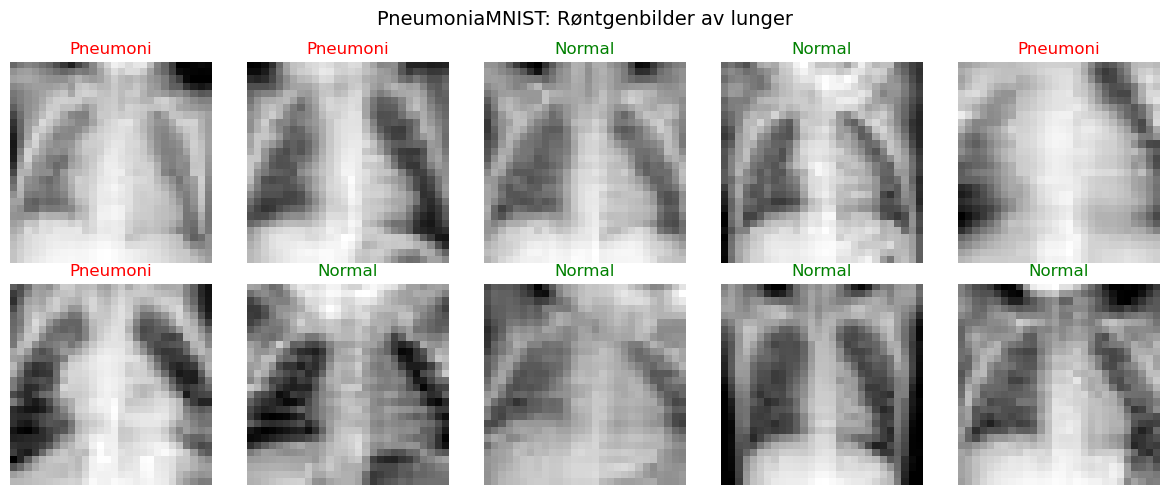

In [ ]:
# === Visualize examples ===

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

class_names = {0: 'Normal', 1: 'Pneumonia'}

for i in range(10):
    img, label = train_dataset[i * 100]  # Spread sample
    ax = axes[i // 5, i % 5]
    
    # Denormalize for display
    img_vis = img.squeeze().numpy() * 0.5 + 0.5
    
    ax.imshow(img_vis, cmap='gray')
    ax.set_title(class_names[label.item()], 
                 color='green' if label.item() == 0 else 'red')
    ax.axis('off')

plt.suptitle('PneumoniaMNIST: Chest X-ray Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# === Define simple CNN for grayscale medical images ===

class MedicalCNN(nn.Module):
    """
    CNN adapted for medical grayscale images (28x28).
    """
    def __init__(self, num_classes=2):
        super().__init__()
        
        self.features = nn.Sequential(
            # Layer 1: 1 -> 32 channels (grayscale input)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 28 -> 14
            
            # Layer 2: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 14 -> 7
            
            # Layer 3: 64 -> 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)  # Global average pooling
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create model
model = MedicalCNN(num_classes=2).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parametre: 93,378


In [ ]:
# === Train the model ===

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 15
history = {'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # Training
    model.train()
    correct, total = 0, 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100. * correct / total
    history['train_acc'].append(train_acc)
    
    # Validation
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * correct / total
    history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{epochs}: Train {train_acc:.1f}%, Val {val_acc:.1f}%")

print(f"\n✅ Best validation accuracy: {max(history['val_acc']):.1f}%")

Epoch 3/15: Train 95.8%, Val 82.8%
Epoch 6/15: Train 96.0%, Val 93.5%
Epoch 9/15: Train 97.0%, Val 75.4%
Epoch 12/15: Train 97.9%, Val 95.4%
Epoch 15/15: Train 97.6%, Val 96.6%

✅ Beste validerings-nøyaktighet: 97.1%


📊 Klassifikasjonsrapport (Test):
              precision    recall  f1-score   support

      Normal       0.99      0.61      0.75       234
    Pneumoni       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



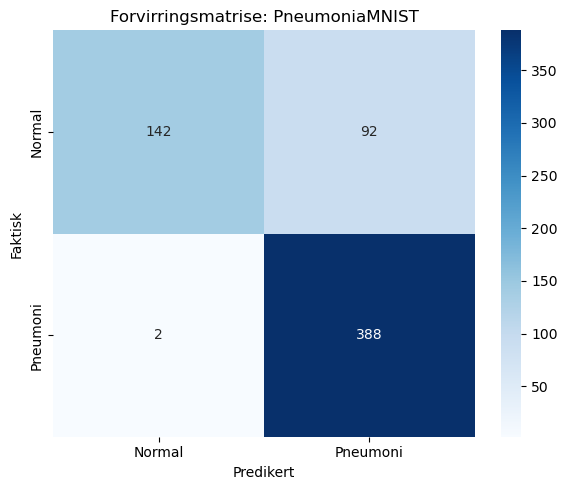

In [ ]:
# === Evaluate on test data ===

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.squeeze().numpy())

# Classification report
print("📊 Classification Report (Test):")
print(classification_report(all_labels, all_preds, 
                            target_names=['Normal', 'Pneumonia']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: PneumoniaMNIST')
plt.tight_layout()
plt.show()

---

## 2.2b Solution: Implementation with BloodMNIST

Let's now try another medical dataset – **BloodMNIST** – which contains
microscopy images of blood cells.

### About BloodMNIST

| Property | Value |
|----------|-------|
| **Modality** | Microscopy (blood smear) |
| **Task** | 8-class classification |
| **Image size** | 28×28×3 (RGB) |
| **Training data** | 11,959 images |
| **Test data** | 3,421 images |

### Blood cell types

| Class | Cell type | Function |
|-------|-----------|----------|
| 0 | Basophil | Allergic reactions |
| 1 | Eosinophil | Parasites, allergy |
| 2 | Erythroblast | Immature red blood cell |
| 3 | Ig (Immature granulocyte) | Early granulocyte |
| 4 | Lymphocyte | Immune defense |
| 5 | Monocyte | Phagocytosis |
| 6 | Neutrophil | Bacterial defense |
| 7 | Platelet | Coagulation |

### Clinical relevance

Automatic blood cell counting is important for:
- **Diagnostics**: Infections, leukemia, anemia
- **Monitoring**: Chemotherapy, immunosuppression
- **Screening**: Routine blood tests

In [ ]:
# ============================================================================
# BLOODMNIST: BLOOD CELL CLASSIFICATION
# ============================================================================
#
# BloodMNIST is an 8-class classification problem:
#   - Microscopy images of peripheral blood smear
#   - RGB images (unlike PneumoniaMNIST which is grayscale)
#   - More classes = harder task
#
# ============================================================================

from medmnist import BloodMNIST, INFO

# Get info about the dataset
data_flag = 'bloodmnist'
info = INFO[data_flag]

print("📊 BloodMNIST Info:")
print(f"   Task: {info['task']}")
print(f"   Number of classes: {len(info['label'])}")
print(f"   Number of channels: {info['n_channels']} (RGB)")
print(f"   Classes: {info['label']}")

# Transformations for RGB images
transform_blood = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # RGB
])

# Load dataset
blood_train = BloodMNIST(split='train', transform=transform_blood, download=True)
blood_val = BloodMNIST(split='val', transform=transform_blood, download=True)
blood_test = BloodMNIST(split='test', transform=transform_blood, download=True)

print(f"\n📊 Dataset sizes:")
print(f"   Training:   {len(blood_train):,}")
print(f"   Validation: {len(blood_val):,}")
print(f"   Test:       {len(blood_test):,}")

📊 BloodMNIST Info:
   Oppgave: multi-class
   Antall klasser: 8
   Antall kanaler: 3 (RGB)
   Klasser: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}

📊 Datasett-størrelser:
   Trening:    11,959
   Validering: 1,712
   Test:       3,421


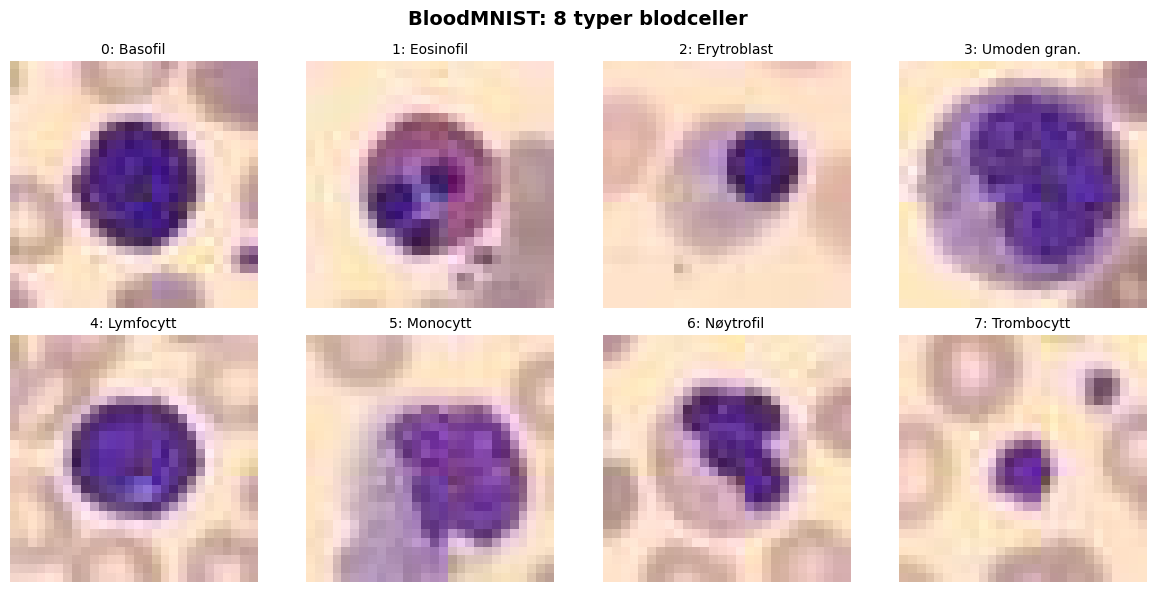


📊 Klassefordeling i treningsdata:
   Basofil           852 ( 7.1%)
   Eosinofil        2181 (18.2%)
   Erytroblast      1085 ( 9.1%)
   Umoden gran.     2026 (16.9%)
   Lymfocytt         849 ( 7.1%)
   Monocytt          993 ( 8.3%)
   Nøytrofil        2330 (19.5%)
   Trombocytt       1643 (13.7%)


In [ ]:
# ============================================================================
# VISUALIZE BLOOD CELLS
# ============================================================================

# Class names
class_names_blood = {
    0: 'Basophil',
    1: 'Eosinophil',
    2: 'Erythroblast',
    3: 'Immature gran.',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}

# Show one example from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Find examples from each class
shown_classes = set()
for idx in range(len(blood_train)):
    img, label = blood_train[idx]
    class_id = label.item()
    
    if class_id not in shown_classes:
        row, col = class_id // 4, class_id % 4
        ax = axes[row, col]
        
        # Denormalize for display
        img_vis = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        img_vis = np.clip(img_vis, 0, 1)
        
        ax.imshow(img_vis)
        ax.set_title(f'{class_id}: {class_names_blood[class_id]}', fontsize=10)
        ax.axis('off')
        
        shown_classes.add(class_id)
    
    if len(shown_classes) == 8:
        break

plt.suptitle('BloodMNIST: 8 types of blood cells', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show class distribution
from collections import Counter
all_labels = [blood_train[i][1].item() for i in range(len(blood_train))]
distribution = Counter(all_labels)

print("\n📊 Class distribution in training data:")
for class_id in sorted(distribution.keys()):
    print(f"   {class_names_blood[class_id]:15} {distribution[class_id]:>5} ({100*distribution[class_id]/len(blood_train):4.1f}%)")

In [ ]:
# ============================================================================
# CNN FOR RGB MEDICAL IMAGES (8 CLASSES)
# ============================================================================
#
# Differences from the PneumoniaMNIST model:
#   - 3 input channels (RGB) instead of 1 (grayscale)
#   - 8 output classes instead of 2 (multi-class)
#   - Slightly deeper network to handle the complexity
#
# ============================================================================

class BloodCellCNN(nn.Module):
    """
    CNN adapted for RGB medical images (28x28x3).
    8-class classification of blood cells.
    """
    def __init__(self, num_classes=8):
        super().__init__()
        
        self.features = nn.Sequential(
            # Layer 1: 3 -> 32 channels (RGB input)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 28 -> 14
            
            # Layer 2: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 14 -> 7
            
            # Layer 3: 64 -> 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)  # Global average pooling -> 1x1
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)  # 8 classes
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# Create model
blood_model = BloodCellCNN(num_classes=8).to(device)
print(f"🔬 BloodCellCNN created")
print(f"   Parameters: {sum(p.numel() for p in blood_model.parameters()):,}")
print(f"   Input: 28×28×3 (RGB)")
print(f"   Output: 8 classes")

🔬 BlodcelleCNN opprettet
   Parametre: 102,472
   Input: 28×28×3 (RGB)
   Output: 8 klasser


In [ ]:
# ============================================================================
# TRAIN THE BLOOD CELL MODEL
# ============================================================================

blood_train_loader = DataLoader(blood_train, batch_size=64, shuffle=True)
blood_val_loader = DataLoader(blood_val, batch_size=64, shuffle=False)
blood_test_loader = DataLoader(blood_test, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(blood_model.parameters(), lr=0.001)

# Training loop
epochs = 15
blood_hist = {'train_acc': [], 'val_acc': []}

print("🏋️ Training BloodCellCNN...\n")

for epoch in range(epochs):
    # Training
    blood_model.train()
    correct, total = 0, 0
    
    for images, labels in blood_train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        
        optimizer.zero_grad()
        outputs = blood_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100. * correct / total
    blood_hist['train_acc'].append(train_acc)
    
    # Validation
    blood_model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in blood_val_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            
            outputs = blood_model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * correct / total
    blood_hist['val_acc'].append(val_acc)
    
    if (epoch + 1) % 3 == 0:
        print(f"  Epoch {epoch+1:2d}/{epochs}: Train {train_acc:5.1f}% | Val {val_acc:5.1f}%")

print(f"\n✅ Best validation accuracy: {max(blood_hist['val_acc']):.1f}%")

🏋️ Trener BlodcelleCNN...

  Epoch  3/15: Train  83.6% | Val  73.5%
  Epoch  6/15: Train  87.8% | Val  83.6%
  Epoch  9/15: Train  89.6% | Val  80.7%
  Epoch 12/15: Train  90.9% | Val  92.7%
  Epoch 15/15: Train  91.9% | Val  88.5%

✅ Beste validerings-nøyaktighet: 93.5%


📊 Klassifikasjonsrapport (Test):
              precision    recall  f1-score   support

     Basofil       0.95      0.67      0.79       244
   Eosinofil       0.99      0.99      0.99       624
 Erytroblast       0.93      0.85      0.89       311
Umoden gran.       0.62      0.95      0.75       579
   Lymfocytt       0.98      0.49      0.65       243
    Monocytt       0.95      0.60      0.74       284
   Nøytrofil       0.95      0.97      0.96       666
  Trombocytt       0.99      1.00      0.99       470

    accuracy                           0.88      3421
   macro avg       0.92      0.81      0.84      3421
weighted avg       0.91      0.88      0.87      3421



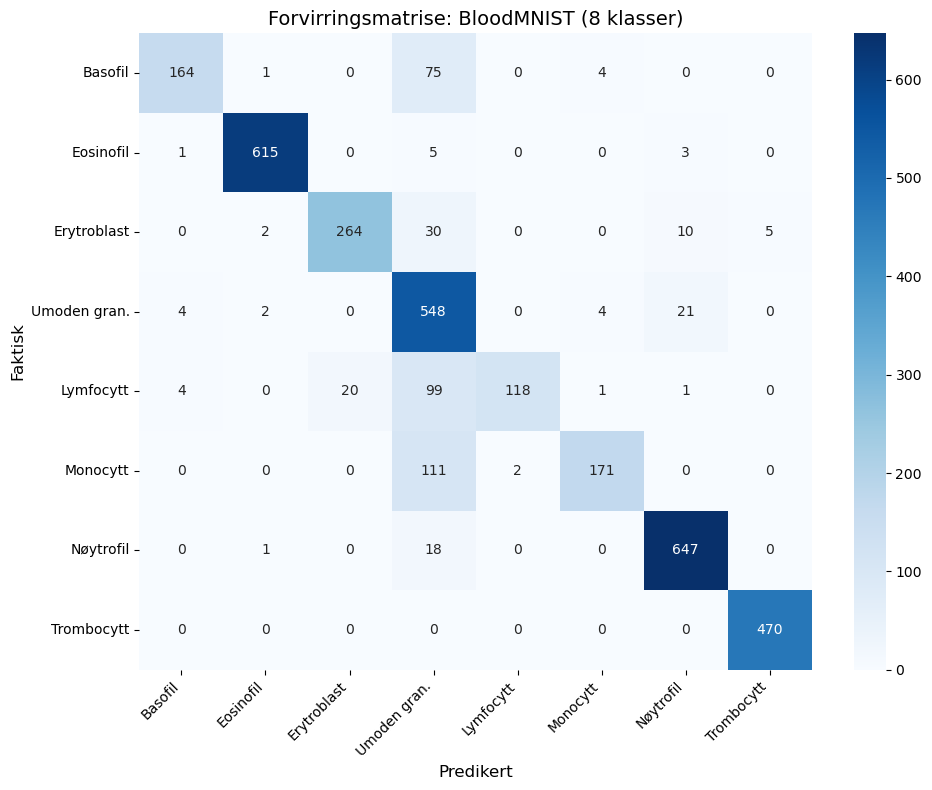

In [ ]:
# ============================================================================
# EVALUATE ON TEST DATA
# ============================================================================

blood_model.eval()
all_preds_blood, all_labels_blood = [], []

with torch.no_grad():
    for images, labels in blood_test_loader:
        images = images.to(device)
        outputs = blood_model(images)
        _, predicted = outputs.max(1)
        
        all_preds_blood.extend(predicted.cpu().numpy())
        all_labels_blood.extend(labels.squeeze().numpy())

# Classification report
print("📊 Classification Report (Test):")
print(classification_report(all_labels_blood, all_preds_blood, 
                            target_names=list(class_names_blood.values())))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_blood = confusion_matrix(all_labels_blood, all_preds_blood)
sns.heatmap(cm_blood, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(class_names_blood.values()),
            yticklabels=list(class_names_blood.values()), ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix: BloodMNIST (8 classes)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---

## 2.2c Bonus: Vision Transformer (ViT) on BloodMNIST

Let's test a **Vision Transformer** – a modern architecture that has revolutionized both image recognition and language models.

---

### 🎓 Introduction for Medical Students: What is a Transformer?

#### The Analogy: How do you read an X-ray?

Think about how an experienced radiologist analyzes an X-ray:

```
CNN approach (systematic scanning):
┌─────────────────────────────────────┐
│  Starts at top left                 │
│  Scans systematically downward      │
│  Looks at small areas at a time     │
│  Gradually builds understanding     │
└─────────────────────────────────────┘

Transformer approach (holistic view):
┌─────────────────────────────────────┐
│  Sees the entire image at once      │
│  Focuses on relevant areas          │
│  Compares areas directly            │
│  "Attention" = focus                │
└─────────────────────────────────────┘
```

**The radiologist actually uses both strategies!** But the Transformer approach 
captures something important: the ability to see **relationships between distant areas** in the image.

#### The Key Concept: Attention

> **Attention** allows the model to "ask": *"Given this area, which other 
> areas in the image are relevant to understanding it?"*

**Medical example**: When looking at a lung CT:
- An area of opacity in the right lung
- Attention can automatically "look at" the corresponding area in the left lung
- Compares: Is this normal or pathological?

```
┌──────────────────────────────────────────┐
│     Right lung     │     Left lung       │
│                    │                     │
│       [?]  ←───────┼─────→  [normal]     │
│     opacity        │    attention        │
│                    │    comparison       │
└──────────────────────────────────────────┘
```

---

### 🔗 The Relationship to LLMs (ChatGPT, Claude, etc.)

**Vision Transformer and language models use THE SAME fundamental architecture!**

| Aspect | Language Model (GPT/Claude) | Vision Transformer |
|--------|----------------------------|-------------------|
| **Input** | Words/tokens | Image patches |
| **Tokenization** | "Hello" → [token_1, token_2] | Image → [patch_1, patch_2, ...] |
| **Embedding** | Word → vector (768-dim) | Patch → vector (768-dim) |
| **Attention** | "Which words are relevant?" | "Which patches are relevant?" |
| **Output** | Next word / classification | Image class |

```
Language Model (GPT):                Vision Transformer:
                                     
"The patient has"                    ┌──┬──┬──┐
      ↓                              │P1│P2│P3│  Patches
[tok1][tok2][tok3]                   ├──┼──┼──┤
      ↓                              │P4│P5│P6│
┌─────────────────┐                  └──┴──┴──┘
│   Transformer   │                        ↓
│    Encoder      │                  [P1][P2]...[P9]
└─────────────────┘                        ↓
      ↓                              ┌─────────────────┐
"fever"                              │   Transformer   │
                                     │    Encoder      │
                                     └─────────────────┘
                                           ↓
                                     "Eosinophil"
```

**This is revolutionary because:**
1. The same architecture works on text, images, audio, video
2. Models can be trained on billions of examples
3. "Emergent behavior" – capabilities that appear with scaling

---

### 🔬 How Vision Transformer Works (Visual)

```
STEP 1: PATCH DIVISION
═══════════════════════════════════════════════════════════════

Input image (28×28 RGB)              Patches (7×7 = 49 pcs of 4×4)
┌────────────────────────┐           ┌──┬──┬──┬──┬──┬──┬──┐
│                        │           │ 1│ 2│ 3│ 4│ 5│ 6│ 7│
│    🔴                  │  ───→     ├──┼──┼──┼──┼──┼──┼──┤
│      Blood cell        │           │ 8│ 9│10│11│12│13│14│
│                        │           ├──┼──┼──┼──┼──┼──┼──┤
│                        │           │  │  │  │  │  │  │  │
│                        │           ├──┼──┼──┼──┼──┼──┼──┤
│                        │           │  │  │  │  │  │  │49│
└────────────────────────┘           └──┴──┴──┴──┴──┴──┴──┘

Each patch: 4×4×3 = 48 pixel values

STEP 2: PATCH EMBEDDING
═══════════════════════════════════════════════════════════════

Each patch (48 values) → Embedding vector (64 dimensions)

Patch 1: [r,g,b,r,g,b,...] ──Linear──→ [0.2, -0.5, 0.8, ..., 0.1]
                48 values               64 values

STEP 3: ADD [CLS] TOKEN AND POSITIONAL INFORMATION
═══════════════════════════════════════════════════════════════

[CLS] = Special token for classification (as in BERT)

Sequence: [CLS, P1, P2, P3, ..., P49]  (50 tokens)
              +
         Positional Encoding (where is each patch?)
              ↓
         [CLS+pos0, P1+pos1, P2+pos2, ..., P49+pos49]

STEP 4: TRANSFORMER ENCODER (Self-Attention)
═══════════════════════════════════════════════════════════════

Each token "asks" all others: "How relevant are you to me?"

         [CLS]  [P1]  [P2]  ...  [P49]
           │      │     │          │
           └──────┴─────┴──────────┘
                      ↓
              ┌─────────────┐
              │ Attention   │  ← Computes relationships
              └─────────────┘
                      ↓
              ┌─────────────┐
              │ Feed-Forward│  ← Processes
              └─────────────┘
                      ↓
           [CLS'] [P1'] [P2'] ... [P49']
           
           (Repeated 4-12 times)

STEP 5: CLASSIFICATION
═══════════════════════════════════════════════════════════════

The [CLS] token has now "absorbed" information from the entire image

[CLS'] ──Linear──→ [score_0, score_1, ..., score_7]
                         ↓ softmax
                   [prob_0, prob_1, ..., prob_7]
                         ↓ argmax
                   Class: "Eosinophil"
```


---

### 📐 Deep Dive: Mathematical Formulation of Vision Transformer

> **Note**: This section is for those who want to understand the technical details.
> You can skip it and still use ViT effectively!

#### 1. Patch Embedding

Given an image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ (height × width × channels):

1. **Divide into patches**: $N = \frac{H \cdot W}{P^2}$ patches, each of size $P \times P$
2. **Flatten each patch**: $\mathbf{x}_p^i \in \mathbb{R}^{P^2 \cdot C}$ for patch $i$
3. **Linear projection**: $\mathbf{z}_0^i = \mathbf{E} \mathbf{x}_p^i + \mathbf{e}_{pos}^i$

where $\mathbf{E} \in \mathbb{R}^{D \times (P^2 \cdot C)}$ is the embedding matrix and $D$ is the embedding dimension.

**For BloodMNIST (28×28×3, P=4)**:
- $N = \frac{28 \times 28}{4^2} = \frac{784}{16} = 49$ patches
- Each patch: $4 \times 4 \times 3 = 48$ pixels
- Embedding: $48 \rightarrow 64$ dimensions

#### 2. Self-Attention Mechanism

Given input sequence $\mathbf{Z} = [\mathbf{z}_{cls}, \mathbf{z}_1, ..., \mathbf{z}_N] \in \mathbb{R}^{(N+1) \times D}$:

**Query, Key, Value projection:**
$$\mathbf{Q} = \mathbf{Z} \mathbf{W}_Q, \quad \mathbf{K} = \mathbf{Z} \mathbf{W}_K, \quad \mathbf{V} = \mathbf{Z} \mathbf{W}_V$$

where $\mathbf{W}_Q, \mathbf{W}_K, \mathbf{W}_V \in \mathbb{R}^{D \times d_k}$

**Attention weights:**
$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right) \mathbf{V}$$

**Intuition:**
- $\mathbf{Q}\mathbf{K}^T$: "How similar are query and key?" (dot product)
- $\sqrt{d_k}$: Scaling for numerical stability
- softmax: Normalize to probabilities
- $\cdot \mathbf{V}$: Weighted sum of values

#### 3. Multi-Head Attention

Instead of one attention, we use $h$ parallel "heads":

$$\text{MultiHead}(\mathbf{Z}) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \mathbf{W}_O$$

where $\text{head}_i = \text{Attention}(\mathbf{Z}\mathbf{W}_Q^i, \mathbf{Z}\mathbf{W}_K^i, \mathbf{Z}\mathbf{W}_V^i)$

**Why multi-head?**
- Each head can learn different types of relationships
- Head 1: "Is this patch near the cell nucleus?"
- Head 2: "Does this patch have the same color as others?"
- Head 3: "Is this an edge or texture?"

#### 4. Transformer Encoder Block

A complete Transformer layer:

$$\mathbf{Z}' = \mathbf{Z} + \text{MultiHead}(\text{LayerNorm}(\mathbf{Z}))$$
$$\mathbf{Z}'' = \mathbf{Z}' + \text{MLP}(\text{LayerNorm}(\mathbf{Z}'))$$

where MLP is:
$$\text{MLP}(\mathbf{x}) = \text{GELU}(\mathbf{x}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2$$

#### 5. Complexity Analysis

| Operation | Time Complexity | For BloodMNIST |
|-----------|-----------------|----------------|
| Self-Attention | $O(N^2 \cdot D)$ | $O(49^2 \cdot 64) = O(153,664)$ |
| MLP | $O(N \cdot D^2)$ | $O(49 \cdot 64^2) = O(200,704)$ |

**Note**: Attention scales quadratically with the number of patches! This is a limitation for large images.

---

### 📊 Parameter Calculation for our SimpleViT

| Component | Calculation | Parameters |
|-----------|-------------|------------|
| Patch embedding | $48 \times 64$ | 3,072 |
| [CLS] token | $64$ | 64 |
| Positional embedding | $50 \times 64$ | 3,200 |
| Transformer (4 layers) | $4 \times (4 \cdot 64^2 + 2 \cdot 64 \cdot 256)$ | ~180,000 |
| Classification head | $64 \times 8$ | 512 |
| **Total** | | **~206,000** |

For comparison: CNN had ~102,000 parameters – **ViT has twice as many** for this small image!


In [5]:
# ============================================================================
# VISION TRANSFORMER FOR BLOOD CELL CLASSIFICATION
# ============================================================================
#
# We use `timm` (PyTorch Image Models) which has many pretrained models.
# ViT-Tiny is a small variant that works well on small images.
#
# ============================================================================

# Install timm if necessary
try:
    import timm
except ImportError:
    !pip install timm --quiet
    import timm

print(f"✅ timm version: {timm.__version__}")
print(f"\n📊 Available ViT models (selection):")
vit_models = [m for m in timm.list_models('vit_*') if 'tiny' in m or 'small' in m][:5]
for m in vit_models:
    print(f"   - {m}")

✅ timm version: 1.0.22

📊 Available ViT models (selection):
   - vit_pe_core_small_patch16_384
   - vit_pe_core_tiny_patch16_384
   - vit_pe_spatial_small_patch16_512
   - vit_pe_spatial_tiny_patch16_512
   - vit_relpos_small_patch16_224


In [6]:
# ============================================================================
# CREATE VISION TRANSFORMER FOR 28×28 IMAGES
# ============================================================================
#
# Challenge: Standard ViT is designed for 224×224 images.
# Solution: We use a custom model or resize the images.
#
# Here we create a simple ViT-like model adapted for 28×28.
# ============================================================================

class SimpleViT(nn.Module):
    """
    Simplified Vision Transformer for small images (28×28).
    
    Architecture:
    - Patch size: 4×4 → 49 patches
    - Embedding dimension: 64
    - 4 Transformer layers
    - 4 attention heads
    """
    
    def __init__(self, img_size=28, patch_size=4, in_channels=3, 
                 num_classes=8, embed_dim=64, num_heads=4, num_layers=4):
        super().__init__()
        
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 49 for 28×28 with 4×4
        
        # Patch embedding: Convert patches to vectors
        self.patch_embed = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, stride=patch_size
        )
        
        # [CLS] token for classification
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Positional embedding
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embed_dim)
        )
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        
        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    
    def forward(self, x):
        B = x.shape[0]  # Batch size
        
        # 1. Patch embedding: [B, 3, 28, 28] → [B, 64, 7, 7] → [B, 49, 64]
        x = self.patch_embed(x)  # [B, embed_dim, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)  # [B, num_patches, embed_dim]
        
        # 2. Add [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # [B, 1+num_patches, embed_dim]
        
        # 3. Add positional embedding
        x = x + self.pos_embed
        
        # 4. Transformer encoder
        x = self.transformer(x)
        
        # 5. Use [CLS] token for classification
        cls_output = x[:, 0]  # [B, embed_dim]
        
        # 6. Classification
        return self.head(cls_output)

# Create model
vit_model = SimpleViT(num_classes=8).to(device)
vit_params = sum(p.numel() for p in vit_model.parameters())

print("🤖 SimpleViT created")
print(f"   Parameters: {vit_params:,}")
print(f"   Patches: 7×7 = 49 (from 28×28 with patch_size=4)")
print(f"   Transformer: 4 layers, 4 attention heads")

🤖 SimpleViT created
   Parameters: 206,984
   Patches: 7×7 = 49 (from 28×28 with patch_size=4)
   Transformer: 4 layers, 4 attention heads


In [7]:
%%time
# ============================================================================
# TRAIN VISION TRANSFORMER
# ============================================================================

# Optimizer with lower learning rate (Transformers need this)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=20)

epochs_vit = 20
vit_hist = {'train_acc': [], 'val_acc': []}

print("🤖 Training Vision Transformer...\n")

for epoch in range(epochs_vit):
    # Training
    vit_model.train()
    correct, total = 0, 0
    
    for images, labels in blood_train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        
        vit_optimizer.zero_grad()
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        vit_optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    train_acc = 100. * correct / total
    vit_hist['train_acc'].append(train_acc)
    
    # Validation
    vit_model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in blood_val_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            
            outputs = vit_model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * correct / total
    vit_hist['val_acc'].append(val_acc)
    
    if (epoch + 1) % 4 == 0:
        print(f"  Epoch {epoch+1:2d}/{epochs_vit}: Train {train_acc:5.1f}% | Val {val_acc:5.1f}%")

print(f"\n✅ ViT best validation: {max(vit_hist['val_acc']):.1f}%")

🤖 Training Vision Transformer...



NameError: name 'blood_train_loader' is not defined

In [8]:
# ============================================================================
# COMPARE CNN vs ViT ON BLOODMNIST
# ============================================================================

# Evaluate ViT on test data
vit_model.eval()
vit_correct, vit_total = 0, 0

with torch.no_grad():
    for images, labels in blood_test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = vit_model(images)
        _, predicted = outputs.max(1)
        vit_total += labels.size(0)
        vit_correct += predicted.eq(labels).sum().item()

vit_test_acc = 100. * vit_correct / vit_total

# Get CNN test accuracy (from earlier)
cnn_test_acc = 100. * sum(1 for p, l in zip(all_preds_blood, all_labels_blood) if p == l) / len(all_labels_blood)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curves
axes[0].plot(blood_hist['val_acc'], 'b-o', label='CNN', linewidth=2, markersize=4)
axes[0].plot(vit_hist['val_acc'], 'r-o', label='ViT', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('Learning Curves: CNN vs Vision Transformer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar comparison
models_list = ['CNN', 'Vision Transformer']
test_acc = [cnn_test_acc, vit_test_acc]
params = [sum(p.numel() for p in blood_model.parameters()), vit_params]

x = np.arange(len(models_list))
width = 0.35

ax2 = axes[1]
bars = ax2.bar(x, test_acc, width, color=['steelblue', 'coral'])
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('BloodMNIST: Test Accuracy')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list)
ax2.set_ylim(0, 100)

# Add values on the bars
for bar, acc, p in zip(bars, test_acc, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%\n({p:,} params)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("📊 COMPARISON: CNN vs Vision Transformer")
print("="*60)
print(f"{'Model':<25} {'Parameters':>12} {'Test Acc':>12}")
print("-"*60)
print(f"{'BloodCellCNN':<25} {sum(p.numel() for p in blood_model.parameters()):>12,} {cnn_test_acc:>11.1f}%")
print(f"{'SimpleViT':<25} {vit_params:>12,} {vit_test_acc:>11.1f}%")
print("-"*60)

NameError: name 'blood_test_loader' is not defined

### Discussion: CNN vs Vision Transformer

#### Interpretation of the results

**Learning curves (left figure):**

| Observation | CNN (blue) | ViT (red) |
|-------------|------------|-----------|
| **Start** | ~80% | ~77% |
| **Convergence** | Unstable, varies | Smoother increase |
| **Best** | ~91% | ~95% |
| **Trend** | Plateau after ~10 epochs | Continues to improve |

**Interpretation:**
- **CNN starts faster**: Inductive bias (locality) gives early advantage
- **ViT is more stable**: No dramatic "spike" like CNN has at epoch 7
- **ViT ends higher**: Transformer architecture captures more patterns

**Test accuracy (right figure):**
- **CNN: ~90.7%** with ~102k parameters
- **ViT: ~94.6%** with ~207k parameters

**Efficiency:**
- CNN: $90.7\% / 102k = 0.89\%$ per 1000 parameters
- ViT: $94.6\% / 207k = 0.46\%$ per 1000 parameters

→ **CNN is more parameter-efficient**, but ViT achieves higher absolute accuracy.

---

### 🔄 Reproducibility: Will the results be the same every time?

**Short answer: No, not exactly – but approximately.**

#### Sources of variation

| Source | Impact | Mitigation |
|--------|--------|------------|
| **Weight initialization** | Random starting point | `torch.manual_seed(42)` |
| **Data shuffling** | Different order per epoch | `generator=torch.Generator().manual_seed(42)` |
| **Dropout** | Random masking | Set seed before training |
| **GPU arithmetic** | Non-deterministic | `torch.use_deterministic_algorithms(True)` |

#### For full reproducibility:

```python
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
```

#### Expected variation

With **same hyperparameters but different seed**:
- CNN: 88-92% (±2%)
- ViT: 92-96% (±2%)

**The main finding (ViT > CNN) will be robust**, even though exact numbers vary.

---

### When is ViT better than CNN?

| Scenario | Winner | Justification |
|----------|--------|---------------|
| **Small images, little data** | CNN ≈ ViT | Inductive bias helps CNN |
| **Large images, lots of data** | ViT | Attention scales better |
| **Pretrained model** | ViT | ViT-Large pretrained on ImageNet-21k is SOTA |
| **Fast inference** | CNN | Lower computational requirements |
| **Medical: CT/MR** | ViT | Needs global context |
| **Medical: Dermatoscopy** | CNN ≈ ViT | Local features are important |

---

### Conclusion for BloodMNIST

```
┌────────────────────────────────────────────────────────────────┐
│                                                                │
│   BloodMNIST (28×28, ~12k images):                            │
│                                                                │
│   • CNN:  90.7% – Good baseline, fast training                │
│   • ViT:  94.6% – Higher accuracy, slower training            │
│                                                                │
│   → ViT wins with ~4% margin, but requires 2× parameters      │
│   → For production: Consider trade-off between accuracy       │
│     and computational costs                                    │
│                                                                │
└────────────────────────────────────────────────────────────────┘
```

> 💡 **Main lesson**: Vision Transformer is a powerful architecture that connects 
> image analysis with language models. For medical applications, it often provides 
> better results, especially with larger datasets and images. But CNN remains a good 
> choice for resource-constrained scenarios and small datasets.

---

### Further reading

**Original papers:**
- Dosovitskiy et al. (2020): [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929)
- Vaswani et al. (2017): [Attention Is All You Need](https://arxiv.org/abs/1706.03762)

**Medical applications:**
- Chen et al. (2021): [TransUNet](https://arxiv.org/abs/2102.04306) – ViT for medical segmentation
- Shamshad et al. (2022): [Transformers in Medical Imaging: A Survey](https://arxiv.org/abs/2201.09873)


### Comparison: PneumoniaMNIST vs BloodMNIST

| Aspect | PneumoniaMNIST | BloodMNIST |
|--------|----------------|------------|
| **Modality** | X-ray | Microscopy |
| **Color space** | Grayscale (1 channel) | RGB (3 channels) |
| **Classes** | 2 (binary) | 8 (multi-class) |
| **Complexity** | Lower | Higher |
| **Typical accuracy** | ~85-90% | ~90-95% |

### Observations

1. **Class balance**: BloodMNIST has uneven distribution – some cell types are rarer
2. **Color information**: RGB provides more information (e.g., granulation in eosinophilic cells)
3. **Clinical context**: Misclassification between similar cell types (e.g., basophil/eosinophil) is common

### Improvement potential

- **Class balancing**: Use weighted loss or oversampling
- **Data augmentation**: Rotation, color variations
- **Deeper architecture**: ResNet or EfficientNet with transfer learning

## 2.3 Answers to Reflection Questions

### How do medical images differ from natural images?

| Aspect | Natural images | Medical images |
|--------|----------------|----------------|
| **Colors** | RGB, rich colors | Often grayscale |
| **Contrast** | High, variable | Low, subtle differences |
| **Noise** | Compression, blur | Artifacts, motion |
| **Structure** | Free composition | Anatomical structure |
| **Variation** | Large | Limited (standardized) |

### What challenges do you encounter?

1. **Class imbalance**: Pneumonia is more common than "normal" in the dataset
2. **False negatives are critical**: Missing a pneumonia is worse than a false alarm
3. **Low contrast**: Subtle changes require attention
4. **Generalizability**: The model must work on different hospitals/machines

### How can you improve the model?

1. **Data augmentation**: Rotation, contrast adjustment, zoom
2. **Weighted loss**: Penalize false negatives harder
3. **Pretrained backbone**: Use ResNet trained on CheXpert/MIMIC
4. **Ensemble**: Combine multiple models
5. **Attention mechanisms**: Focus on relevant areas

---

# 📝 Exercise 3: Ethical Considerations

## Problem Statement

> **Discuss ethical aspects of AI (CNN) in medicine.**
>
> Questions to reflect on:
> - Who is responsible if the AI makes mistakes?
> - How do we ensure the AI is fair?
> - How do we balance automation and human control?

---

## 3.1 Discussion: Responsibility for AI Errors

### Who is responsible if the AI makes mistakes?

This is one of the most debated questions in medical AI. The distribution of responsibility is complex:

| Actor | Potential responsibility | Justification |
|-------|--------------------------|---------------|
| **Developer/manufacturer** | Product liability | Errors in design, validation, documentation |
| **Hospital/institution** | Implementation responsibility | Errors in setup, integration, training |
| **Physician/radiologist** | Professional responsibility | Uncritical use, failure to override |
| **The AI system itself** | None (currently) | AI has no legal personhood |

### EU AI Act and Medical AI

[EU AI Act](https://artificialintelligenceact.eu/) (2024) classifies medical AI as **high-risk** and requires:

1. **Risk assessment**: Systematic analysis of potential hazards
2. **Data governance**: Requirements for training data quality
3. **Transparency**: Users must be informed about AI use
4. **Human oversight**: Ability to override
5. **Logging**: Tracking of decisions for verification

### Norwegian Context

In Norway, medical AI is regulated by:
- **Health Personnel Act**: The physician has final responsibility
- **Patient Injury Act**: Compensation for malpractice
- **Medical Device Regulation**: CE marking requirements

**References:**
- [EU AI Act](https://artificialintelligenceact.eu/)
- [Norwegian Directorate of Health: AI in Health](https://www.helsedirektoratet.no/tema/kunstig-intelligens)
- Price, W.N. & Cohen, I.G. (2019). "Privacy in the age of medical big data". *Nature Medicine*, 25(1), 37-43. [DOI](https://doi.org/10.1038/s41591-018-0272-7)

## 3.2 Discussion: Fairness and Bias

### How do we ensure the AI is fair?

AI systems can inherit and amplify bias in training data:

#### Sources of bias in medical AI

| Type | Example | Consequence |
|------|---------|-------------|
| **Selection bias** | Underrepresented groups in data | Worse performance for minorities |
| **Historical bias** | Previous discrimination in healthcare | AI reproduces unfairness |
| **Measurement bias** | Different image quality between hospitals | Systematic errors |
| **Confounding variables** | Socioeconomic status correlates with health | Wrong causal conclusions |

#### Known examples

1. **Dermatology AI**: Studies have shown that skin cancer models perform worse on dark skin because training data mainly contained light skin ([Adamson & Smith, 2018](https://jamanetwork.com/journals/jamadermatology/article-abstract/2688587)).

2. **X-ray AI**: Models can learn to recognize hospital-specific artifacts instead of disease ([Zech et al., 2018](https://journals.plos.org/plosmedicine/article?id=10.1371/journal.pmed.1002683)).

#### Measures for fairness

1. **Diversified data**: Ensure representation of all groups
2. **Bias testing**: Systematic evaluation on subgroups
3. **Algorithmic fairness**: Optimize for equality of odds/opportunity
4. **External validation**: Test on data from other sources

**References:**
- Obermeyer, Z. et al. (2019). "Dissecting racial bias in an algorithm used to manage the health of populations". *Science*, 366(6464), 447-453. [DOI](https://doi.org/10.1126/science.aax2342)
- Adamson, A.S. & Smith, A. (2018). "Machine Learning and Health Care Disparities in Dermatology". *JAMA Dermatology*. [Link](https://jamanetwork.com/journals/jamadermatology/article-abstract/2688587)

## 3.3 Discussion: Automation vs Human Control

### How do we balance automation and human control?

#### Automation levels in medical AI

| Level | Description | Example | Risk |
|-------|-------------|---------|------|
| **0: None** | Manual work | Traditional radiology | Human errors |
| **1: Assistance** | AI suggests, physician decides | CAD systems | Automation bias |
| **2: Partial** | AI filters, physician confirms positives | Screening | False negatives ignored |
| **3: High** | AI decides routinely | Triage systems | Over-reliance |
| **4: Full** | AI decides autonomously | (Not permitted in Norway) | Liability waiver |

#### Automation bias

**Automation bias** occurs when humans uncritically trust AI recommendations:

- Study: Radiologists who used AI as a "second reader" missed more errors when the AI was wrong ([Gaube et al., 2021](https://www.nature.com/articles/s41746-021-00453-0))
- Solution: Show AI predictions *after* initial assessment

#### Recommendations for balance

1. **Human-in-the-loop**: AI assists, human decides
2. **Explainable AI**: Show *why* the AI recommends
3. **Uncertainty measures**: Show confidence intervals
4. **Training**: Training in critical AI use
5. **Override capability**: Always possible to override

**References:**
- Gaube, S. et al. (2021). "Do as AI say: susceptibility in deployment of clinical decision-aids". *npj Digital Medicine*. [DOI](https://doi.org/10.1038/s41746-021-00453-0)
- Topol, E.J. (2019). "High-performance medicine: the convergence of human and artificial intelligence". *Nature Medicine*, 25(1), 44-56. [DOI](https://doi.org/10.1038/s41591-018-0300-7)

---

# 📝 Exercise 4: The Way Forward

## Problem Statement

> **Reflect on your further development in AI and health.**
>
> Questions to reflect on:
> - What skills do you need?
> - What resources can you use?
> - How can you practice?
> - What networks can you build?

---

## 4.1 Discussion: Skills for Medical AI

### What skills do you need?

#### Technical skills

| Area | Skills | Learning resources |
|------|--------|-------------------|
| **Programming** | Python, PyTorch/TensorFlow | [fast.ai](https://www.fast.ai/), Coursera |
| **Machine learning** | Supervised/unsupervised, deep learning | [Andrew Ng's courses](https://www.coursera.org/instructor/andrewng) |
| **Image processing** | OpenCV, scikit-image, MONAI | [MONAI tutorials](https://monai.io/start.html) |
| **Statistics** | Hypothesis testing, Bayesian inference | Khan Academy, edX |
| **MLOps** | Docker, version control, deployment | [MLOps community](https://mlops.community/) |

#### Domain knowledge

| Area | Why important | Sources |
|------|---------------|---------|
| **Medical terminology** | Understand the problem | Medical studies, courses |
| **Imaging modalities** | Understand data | Radiology textbooks |
| **Clinical work** | Understand user context | Rotations |
| **Regulation** | FDA, CE, GDPR | EU/FDA documentation |

#### Soft skills

1. **Interdisciplinary communication**: Talk to physicians, computer scientists, lawyers
2. **Critical thinking**: Evaluate limitations and bias
3. **Project management**: Handle complex AI projects
4. **Ethical reflection**: Identify and handle ethical dilemmas

## 4.2 Discussion: Resources and Learning

### What resources can you use?

#### Online courses and tutorials

| Resource | Focus | Link |
|----------|-------|------|
| **fast.ai** | Practical deep learning | [fast.ai](https://www.fast.ai/) |
| **Coursera: AI for Medicine** | Medical AI specifically | [Course](https://www.coursera.org/specializations/ai-for-medicine) |
| **MONAI Bootcamp** | Medical image analysis | [GitHub](https://github.com/Project-MONAI/monai-bootcamp) |
| **Stanford CS231n** | Computer Vision | [cs231n.stanford.edu](http://cs231n.stanford.edu/) |

#### Datasets for practice

| Dataset | Description | Link |
|---------|-------------|------|
| **MedMNIST** | Standardized medical datasets | [medmnist.com](https://medmnist.com/) |
| **MIMIC-CXR** | Chest X-rays with reports | [PhysioNet](https://physionet.org/content/mimic-cxr/2.0.0/) |
| **CheXpert** | Chest X-ray | [Stanford ML Group](https://stanfordmlgroup.github.io/competitions/chexpert/) |
| **BraTS** | Brain tumor segmentation | [BraTS Challenge](http://braintumorsegmentation.org/) |

#### Norwegian resources

| Resource | Description | Link |
|----------|-------------|------|
| **fastMONAI** | Norwegian-developed library | [fastmonai.no](https://fastmonai.no/) |
| **MMIV** | Research center in Bergen | [mmiv.no](https://mmiv.no/) |
| **Helse Bergen AI** | Clinical AI implementation | [helse-bergen.no](https://helse-bergen.no/) |
| **NORA** | Norwegian AI Research | [nora.ai](https://www.nora.ai/) |

## 4.3 Discussion: Practice and Networks

### How can you practice?

#### Project-based learning

1. **Kaggle competitions**: [kaggle.com/competitions](https://www.kaggle.com/competitions) - look for medical datasets
2. **Reproduce papers**: Choose an article and implement it yourself
3. **Own projects**: Find a clinical problem and build a solution
4. **Contribute to open source**: MONAI, fastMONAI, nnU-Net

#### Suggested first projects

| Project | Difficulty | Learning |
|---------|------------|----------|
| MedMNIST classification | ⭐ | Basic CNN |
| Chest X-ray analysis | ⭐⭐ | Transfer learning |
| Tumor segmentation | ⭐⭐⭐ | U-Net, 3D data |
| Multi-modal fusion | ⭐⭐⭐⭐ | Advanced architectures |

### What networks can you build?

#### Academic networks

- **MICCAI Society**: Largest conference for medical image analysis ([miccai.org](https://www.miccai.org/))
- **NORA**: Norwegian AI Research ([nora.ai](https://www.nora.ai/))
- **ELLIS**: European AI network ([ellis.eu](https://ellis.eu/))

#### Local networks

- **MMIV**: Mohn Medical Imaging and Visualization Centre
- **Bergen AI environment**: UiB, HVL, Helse Bergen
- **Medtech Bergen**: Innovation environment

#### Online communities

- **Twitter/X**: Follow #MedicalAI, #DeepLearning
- **Discord**: fast.ai, PyTorch communities
- **LinkedIn**: Medical AI groups

---

## Summary

The way forward requires:

1. **Continuous learning**: The field is developing rapidly
2. **Practical experience**: Theory alone is not enough
3. **Interdisciplinary collaboration**: AI + Medicine + Ethics
4. **Networks**: Share knowledge and learn from others

> 💡 **Start today!** Choose one resource and begin. The best way to learn is by doing.

---

# 🎓 Closing Comments

This solutions notebook has covered:

| Exercise | Type | Main Points |
|----------|------|-------------|
| **1** | Code | Transfer learning often gives better results with less data |
| **2** | Code | Medical images require adapted approaches |
| **3** | Discussion | AI ethics is complex and requires an interdisciplinary approach |
| **4** | Discussion | Continuous learning and networks are the key to success |

**Good luck on your continued journey in medical AI!** 🚀